# Some quick start code for TUM Hackathon

In [1]:
from langchain.document_loaders import PyPDFLoader
from ai_eval.config import global_config as glob

filename = "Allplan_2020_Manual.pdf"

loader = PyPDFLoader(f"{glob.DATA_PKG_DIR}/{filename}")

raw_data = loader.load()

texts = [page.page_content for page in raw_data]

print(f"Number of docs: {len(texts)}")

/Users/avosseler/Github/Team/tum-hackathon/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of docs: 319


## (Optional) Preprocess and load data: 

In [2]:
from ai_eval.resources.preprocessor import Preprocessor
from ai_eval.config import global_config as glob

filename = "Allplan_2020_Manual.pdf"

pre = Preprocessor()

docs = pre.fetch_documents(
    blob_path=f"{glob.DATA_PKG_DIR}/{filename}", source="local"
)

documents = pre.chunk_documents(documents=docs)

print(f"Number of processed document chunks: {len(documents)}")

2026-04-13 22:51:50,742 - ai_eval.resources.preprocessor - INFO - Processed /Users/avosseler/Github/Team/tum-hackathon/data/Allplan_2020_Manual.pdf
2026-04-13 22:51:50,750 - ai_eval.resources.preprocessor - INFO - Using SentenceChunker for document chunking.


Finished 'fetch_documents' in 1.9468 secs


🦛 choooooooooooooooooooonk 100% • 319/319 docs chunked [00:01<00:00, 209.99doc/s] 🌱
2026-04-13 22:51:53,888 - ai_eval.resources.preprocessor - INFO - Chunked 319 pages into 319 chunks.


Finished 'chunk_documents' in 3.1476 secs
Number of processed document chunks: 319


## Get annotated data:

In [3]:
from ai_eval.services.file import JSONService
from ai_eval.config import global_config as glob

json = JSONService(path="generated_qa_data_tum.json", root_path=glob.DATA_PKG_DIR, verbose=True)

qa_data = json.doRead()
print(f"Number of evaluation data samples: {len(qa_data)}")

2026-04-13 22:51:53,910 - ai_eval.services.file - INFO - Read: /Users/avosseler/Github/Team/tum-hackathon/data/generated_qa_data_tum.json


Number of evaluation data samples: 100


### Fit RAG model on the generated data and create evaluation dataset

In [4]:
from ai_eval.resources import eval_dataset_builder as eval

ground_truth_contexts = [item["context"] for item in qa_data]
sample_queries = [item["question"] for item in qa_data]
expected_responses = [item["answer"] for item in qa_data]

# ground_truth_contexts = ground_truth_contexts[:20]
# sample_queries = sample_queries[:20]
# expected_responses = expected_responses[:20]

Example: using Vertex AI models

In [5]:
from langchain_google_vertexai import ChatVertexAI, VertexAIEmbeddings

chat_model = ChatVertexAI(
                        project=glob.GCP_PROJECT,
                        model_name="gemini-2.5-flash",
                        temperature=0.1,
                        max_retries=2,
                    )

embedding_model = VertexAIEmbeddings(
                        project=glob.GCP_PROJECT,
                        model_name="text-embedding-005",
                    )

/Users/avosseler/Github/Team/tum-hackathon/.venv/lib/python3.12/site-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils
/Users/avosseler/Github/Team/tum-hackathon/.venv/lib/python3.12/site-packages/vertexai/_model_garden/_model_garden_models.py:278: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


Build a RAG model and inherit from our base class:

In [6]:
from langchain_community.vectorstores import FAISS
from ai_eval.resources.rag_template import FAISSRAG, TFIDFRAG
from ai_eval.resources.get_models import InitModels

models = InitModels()      # LLM generator - RAG

#vectorstore = FAISS.from_documents(documents, embedding_model)

# 1. Create your RAG instance
#rag = FAISSRAG(chat_model, documents, k=3, vectorstore=vectorstore)    # some vanilla example
rag = TFIDFRAG(models.qa_generator, documents, k=5)                 # our (naive) hackathon baseline 

query = "What is Allplan?"

the_relevant_docs = rag.retrieve(question=query)

answer, relevant_docs = rag.answer(question=query)
answer, relevant_docs

/Users/avosseler/Github/Team/tum-hackathon/.venv/lib/python3.12/site-packages/vertexai/_model_garden/_model_garden_models.py:278: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()
2026-04-13 22:52:08,698 - ai_eval.resources.get_models - INFO - Using chat model: gemini-2.5-flash
2026-04-13 22:52:08,699 - ai_eval.resources.get_models - INFO - Using judge model: gemini-2.5-flash
2026-04-13 22:52:08,700 - ai_eval.resources.get_models - INFO - Using embedding model: text-multilingual-embedding-002
2026-04-13 22:52:08,701 - ai_eval.resources.get_models - INFO - Models loaded successfully


('Allplan is a software that offers various tools to control how models and design elements appear on the screen. It is used for designing and modifying elements, designing buildings, and creating key plans, general arrangement drawings, and reinforcement drawings. Allplan has documentation including Help, Manuals, and Tutorials (Basics, Architecture, Engineering). It is associated with CAD and allows users to work on projects in design mode or layout mode.',
 [Document(metadata={}, page_content='Installation, Basics Controlling what’s on your screen 105 Controlling what’s on your screen Allplan offers various tools you can use to control how your model and its design elements appear on the screen. Thus, you can always choose the tool best suited to the task at hand. You can access these tools from various places in Allplan. For example, you can use the View and Window (see "Tools for arranging viewports " on page 71) drop-down lists on the Quick Access Toolbar (on page 21). You can al

Build DeepEval dataset with ground truth and model responses:

In [7]:
# 2. Create the builder with the RAG instance
builder = eval.EvalDatasetBuilder(rag)

# 3. Build the evaluation dataset
evaluation_dataset = builder.build_evaluation_dataset(
    input_contexts=ground_truth_contexts,
    sample_queries=sample_queries,
    expected_responses=expected_responses,
)

Building test dataset: 100%|██████████| 100/100 [05:39<00:00,  3.40s/it]
2026-04-13 22:58:01,740 - ai_eval.resources.eval_dataset_builder - INFO - Evaluation dataset created successfully.


Calculate evaluation metrics:

In [8]:
from ai_eval.resources import deepeval_scorer as deep 

scorer = deep.DeepEvalScorer(evaluation_dataset)

results = scorer.calculate_scores()
print(results)

/Users/avosseler/Github/Team/tum-hackathon/.venv/lib/python3.12/site-packages/vertexai/_model_garden/_model_garden_models.py:278: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()
2026-04-13 22:58:02,659 - ai_eval.resources.get_models - INFO - Using chat model: gemini-2.5-flash
2026-04-13 22:58:02,661 - ai_eval.resources.get_models - INFO - Using judge model: gemini-2.5-flash
2026-04-13 22:58:02,661 - ai_eval.resources.get_models - INFO - Using embedding model: text-multilingual-embedding-002
2026-04-13 22:58:02,662 - ai_eval.resources.get_models - INFO - Models loaded successfully
2026-04-13 22:58:02,662 - ai_eval.resources.deepeval_scorer - INFO - Starting evaluation...


✨ You're running DeepEval's latest Answer Relevancy Metric! (using LangChain Model, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Faithfulness Metric! (using LangChain Model, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Recall Metric! (using LangChain Model, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Contextual Precision Metric! (using LangChain Model, strict=False, 
async_mode=True)...

Evaluating 100 test case(s) in parallel: |          |  0% (0/100) [Time Taken: 00:00, ?test case/s]/Users/avosseler/Github/Team/tum-hackathon/src/ai_eval/utils/utils.py:157: LangChainDeprecationWarning: The method `BaseChatModel.apredict` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~ainvoke` instead.
  res = await chat_model.apredict(prompt)
I0000 00:00:1776113883.107089 25479649 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: unable to get local issuer certificate
I0000 00:00:1776113892.945211 25479648 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: unable to get local issuer certificate
I0000 00:00:1776113902.951470 25479648 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_V



Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.5, strict: False, evaluation model: LangChain Model, reason: The score is 1.00 because the output is perfectly relevant and directly addresses the input query without any extraneous information. Excellent job!, error: None)
  - ✅ Faithfulness (score: 1.0, threshold: 0.7, strict: False, evaluation model: LangChain Model, reason: The score is 1.00 because the actual output is perfectly faithful to the retrieval context, with no contradictions found. Excellent work!, error: None)
  - ✅ Contextual Recall (score: 1.0, threshold: 0.7, strict: False, evaluation model: LangChain Model, reason: The score is 1.00 because the entire expected output is perfectly supported by the 1st node in the retrieval context. Excellent work!, error: None)
  - ✅ Contextual Precision (score: 1.0, threshold: 0.7, strict: False, evaluation model: LangChain Model, reason: The score is 1.00 because the most relevant node, which directly provides the

✓ Tests finished 🎉! Run 'deepeval login' to save and analyze evaluation results on Confident AI.
 
✨👀 Looking for a place for your LLM test data to live 🏡❤️ ? Use Confident AI to get & share testing reports, 
experiment with models/prompts, and catch regressions for your LLM system. Just run 'deepeval login' in the CLI.

2026-04-13 23:00:52,362 - ai_eval.resources.deepeval_scorer - INFO - Evaluation completed successfully!


test_results=[TestResult(name='test_case_2', success=True, metrics_data=[MetricData(name='Answer Relevancy', threshold=0.5, success=True, score=1.0, reason='The score is 1.00 because the output is perfectly relevant and directly addresses the input query without any extraneous information. Excellent job!', strict_mode=False, evaluation_model='LangChain Model', error=None, evaluation_cost=None, verbose_logs='Statements:\n[\n    "To expand or collapse all task areas across different tasks and roles, you need to select and hold Ctrl+Shift while double-clicking within the name line of a task area."\n] \n \nVerdicts:\n[\n    {\n        "verdict": "yes",\n        "reason": null\n    }\n]'), MetricData(name='Faithfulness', threshold=0.7, success=True, score=1.0, reason='The score is 1.00 because the actual output is perfectly faithful to the retrieval context, with no contradictions found. Excellent work!', strict_mode=False, evaluation_model='LangChain Model', error=None, evaluation_cost=Non

In [9]:
custom_weights = {
    'Answer Relevancy': 0.4,
    'Faithfulness': 0.3,
    'Contextual Recall': 0.2,
    'Contextual Precision': 0.1
}

metrics = scorer.get_overall_metrics(metric_weights=custom_weights)
metrics

{'Answer Relevancy': 0.9541381766381767,
 'Faithfulness': 0.9684523809523811,
 'Contextual Recall': 0.96,
 'Contextual Precision': 0.8847222222222222,
 'Average Performance': 0.941828194953195,
 'Weighted Average Performance': 0.9526632071632074}

In [10]:
scorer.get_summary(save_to_file=True)

2026-04-13 23:00:52,406 - ai_eval.resources.deepeval_scorer - INFO - Summary of test results generated successfully!
2026-04-13 23:00:52,425 - ai_eval.services.file - INFO - JSON Service Output to File: /Users/avosseler/Github/Team/tum-hackathon/data/deepeval_results.json


{0: {'query': "How can I expand or collapse all task areas across different tasks and roles in Allplan's user interface?",
  'actual_output': 'To expand or collapse all task areas across different tasks and roles, you need to select and hold **Ctrl+Shift** while double-clicking within the name line of a task area.',
  'expected_output': 'To expand or collapse all areas across tasks and roles, select and hold Ctrl+Shift while double-clicking within the name line of any task area.',
  'actual_context': ["Installation, Basics Allplan's user interface 27 When you point to the name line of a task area, the cursor changes to . You can maximize or minimize a task area by double-clicking within the name line of a task area. A maximized task area shows more tools, which can also have flyout menus. Note : You can expand or collapse all task areas of the task currently selected by selecting and holding the Ctrl key while double- clicking within the name line of a task area. You can expand or coll

I0000 00:00:1776114088.101379 25479650 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: unable to get local issuer certificate
I0000 00:00:1776114178.149506 25479647 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: unable to get local issuer certificate
I0000 00:00:1776114293.213959 25479648 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: unable to get local issuer certificate
I0000 00:00:1776114403.288004 25479645 ssl_transport_security.cc:1884] Handshake failed with error SSL_ERROR_SSL: error:1000007d:SSL routines:OPENSSL_internal:CERTIFICATE_VERIFY_FAILED: unable to get local issuer certificate
I0000 00:00:1776114523.372120 25479643 ssl_transport_security.cc:1884] Handshake failed with error S

### Apply Bayesian Posterior to Each Individual Score

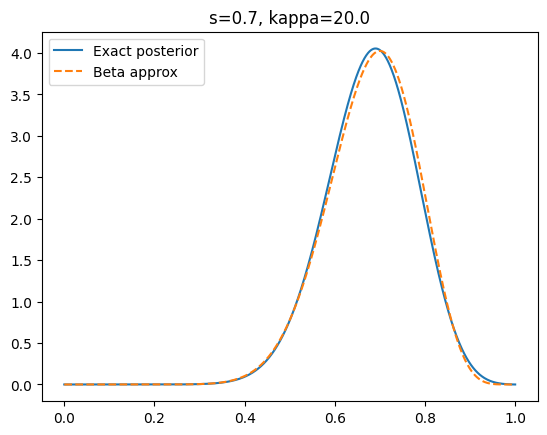

In [ ]:
from typing import Tuple
import numpy as np
import scipy.special as sp


def exact_log_posterior(
    mu: np.ndarray,
    s: float,
    kappa: float,
    a: float = 1.0,
    b: float = 1.0
) -> np.ndarray:
    """
    Compute log posterior (unnormalized) on a grid for exact model.
    Implements a Beta-Beta conjugate model for quantifying uncertainty around each LLM judge score.
    
    Model:
        Likelihood:  s | mu ~ Beta(mu*kappa, (1-mu)*kappa)
        Prior:       mu ~ Beta(a, b)

    Log-posterior (unnormalized):
        log p(mu|s) ∝  log Γ(κ) - log Γ(μκ) - log Γ((1-μ)κ)
                        + (μκ - 1) log s + ((1-μ)κ - 1) log(1-s)
                        + (a-1) log μ + (b-1) log(1-μ)

    This is NOT a standard conjugate update because mu appears inside the
    Gamma functions of the likelihood, making the posterior analytically
    intractable — hence we evaluate it numerically on a grid.
    """

    mu = np.clip(mu, 1e-8, 1 - 1e-8)

    # log likelihood: log p(s | mu) under Beta(mu*kappa, (1-mu)*kappa)
    log_lik = (
        sp.gammaln(kappa)
        - sp.gammaln(mu * kappa)
        - sp.gammaln((1 - mu) * kappa)
        + (mu * kappa - 1) * np.log(s)
        + ((1 - mu) * kappa - 1) * np.log(1 - s)
    )

    # log prior: log p(mu) under Beta(a, b)
    log_prior = (a - 1) * np.log(mu) + (b - 1) * np.log(1 - mu)

    return log_lik + log_prior


def normalize_log_density(logp: np.ndarray, grid: np.ndarray) -> np.ndarray:
    """
    Normalize log-density over grid via numerical integration (trapezoidal rule).
    Subtracts max for numerical stability before exponentiating.
    """
    logp = logp - np.max(logp)
    p = np.exp(logp)
    p /= np.trapezoid(p, grid)
    return p


def beta_approx_density(
    mu: np.ndarray,
    s: float,
    kappa: float,
    a: float = 1.0,
    b: float = 1.0
) -> np.ndarray:
    """
    Moment-matched Beta surrogate to the exact posterior.

    Approximate posterior:
        mu | s ≈ Beta(s*kappa + a, (1-s)*kappa + b)

    This treats the observed score s as contributing kappa pseudo-observations
    with mean s, analogous to Beta-Binomial conjugacy.
    """
    alpha = s * kappa + a
    beta = (1 - s) * kappa + b

    return (
        mu**(alpha - 1)
        * (1 - mu)**(beta - 1)
        / sp.beta(alpha, beta)
    )


def compare_posteriors(
    s: float,
    kappa: float,
    grid_size: int = 1000
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compare exact grid-based posterior vs Beta approximation.

    Returns:
        grid, exact_density, approx_density
    """

    grid = np.linspace(1e-4, 1 - 1e-4, grid_size)

    logp = exact_log_posterior(grid, s, kappa)
    exact = normalize_log_density(logp, grid)

    approx = beta_approx_density(grid, s, kappa)

    return grid, exact, approx


import matplotlib.pyplot as plt

def run_example():
    s = 0.7
    kappa = 20.0

    grid, exact, approx = compare_posteriors(s, kappa)

    plt.plot(grid, exact, label="Exact posterior")
    plt.plot(grid, approx, "--", label="Beta approx")
    plt.legend()
    plt.title(f"s={s}, kappa={kappa}")
    plt.show()
    
run_example()

Given this observed judge score, how uncertain is the true latent quality of this specific item?

In [ ]:
from scipy import stats
import pandas as pd

deepeval_results = scorer.get_summary(save_to_file=False)

# Concentration parameter: controls assumed judge precision.
# Small kappa → wide posteriors (noisy judge), large kappa → narrow (precise judge).
KAPPA = 10.0

posteriors_data = []

for test_idx, test_data in deepeval_results.items():
    for metric_name, score in test_data['metrics'].items():
        if score is not None:
            # Beta approximation posterior parameters:
            #   mu_i | s_i ≈ Beta(alpha_i, beta_i)
            #   alpha_i = s_i * kappa + 1  (prior a=1)
            #   beta_i  = (1 - s_i) * kappa + 1  (prior b=1)
            alpha = score * KAPPA + 1
            beta_param = (1 - score) * KAPPA + 1
            
            # 95% credible interval via inverse CDF of the posterior Beta:
            #   CI = [F^{-1}(0.025; alpha, beta), F^{-1}(0.975; alpha, beta)]
            ci_lower = stats.beta.ppf(0.025, alpha, beta_param)
            ci_upper = stats.beta.ppf(0.975, alpha, beta_param)
            
            # ensure observed score is contained in the CI
            ci_lower = min(ci_lower, score)
            ci_upper = max(ci_upper, score)
            
            posteriors_data.append({
                'test_idx': test_idx,
                'metric': metric_name,
                'score': score,
                'alpha': alpha,
                'beta': beta_param,
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
            })

posteriors_df = pd.DataFrame(posteriors_data)
print(f"Created Beta posteriors for {len(posteriors_df)} individual scores (κ={KAPPA})")
posteriors_df.head(20)

2026-04-14 10:05:22,672 - ai_eval.resources.deepeval_scorer - INFO - Summary of test results generated successfully!


Created Beta posteriors for 400 individual scores (κ=10.0)


,test_idx,metric,score,alpha,beta,ci_lower,ci_upper
0,0,Answer Relevancy,1.000000,11.000000,1.000000,0.715086,1.000000
1,0,Faithfulness,1.000000,11.000000,1.000000,0.715086,1.000000
2,0,Contextual Recall,1.000000,11.000000,1.000000,0.715086,1.000000
3,0,Contextual Precision,1.000000,11.000000,1.000000,0.715086,1.000000
4,1,Answer Relevancy,0.666667,7.666667,4.333333,0.361830,0.872274
5,1,Faithfulness,1.000000,11.000000,1.000000,0.715086,1.000000
6,1,Contextual Recall,1.000000,11.000000,1.000000,0.715086,1.000000
7,1,Contextual Precision,1.000000,11.000000,1.000000,0.715086,1.000000
8,2,Answer Relevancy,1.000000,11.000000,1.000000,0.715086,1.000000
9,2,Faithfulness,1.000000,11.000000,1.000000,0.715086,1.000000


## Hierarchical uncertainty estimation for LLM evaluation pipelines

What is the uncertainty of the average system performance?

In [ ]:
"""
Hierarchical uncertainty estimation for LLM evaluation pipelines.

This implementation estimates a credible interval for the expected evaluation score
of a stochastic 3-stage system:

    1) Data generation (synthesizer):
       X_i → (Q_i, Y_i) ~ p_synth(· | X_i)
       An LLM synthesizer generates Q/A pairs from context chunks.
       This is itself a generative (stochastic) process.

    2) Model generation (RAG):
       Y_hat_i ~ p_model(· | Q_i)
       The RAG system produces an answer for each synthetic question.

    3) Judge evaluation:
       s_i = judge(Q_i, Y_i, Y_hat_i) ∈ [0, 1]
       A continuous score from an LLM judge.

Goal:
    Estimate posterior uncertainty over:
        theta = E[s]

Key challenge:
    Only ONE observed judge score per (Q_i, Y_i, Y_hat_i) is available,
    so judge uncertainty must be modeled rather than empirically estimated.

Approach:

    Outer layer (nonparametric bootstrap):
        Resample the N item indices with replacement.

        IMPORTANT LIMITATION: This resamples the FIXED set of Q/A pairs.
        It captures finite-sample uncertainty — "if we had drawn a different
        subset of these N items, how much would the average shift?"

        It does NOT capture synthesizer generative uncertainty. Running the
        LLM synthesizer again on the same contexts X_i would produce different
        (Q_i', Y_i'), potentially yielding very different scores. To capture
        that, one would need multiple synthesizer draws per context (K > 1).

        What this layer does capture:
        - Finite-sample noise: which items happen to be in the eval set
        - Model sampling variability (Y_hat is fixed per item, so resampling
          items implicitly resamples which model outputs enter the average)

    Inner layer (parametric noise model):
        Treat observed score s_i as a noisy realization of latent mean mu_i:
            s_i | mu_i ~ Beta(mu_i * kappa, (1 - mu_i) * kappa)

        Use empirical Bayes estimate of kappa to control judge noise.

        Approximate posterior:
            mu_i | s_i ≈ Beta(s_i * kappa + a, (1 - s_i) * kappa + b)

Final estimator:
    For each bootstrap iteration:
        - resample items (with replacement)
        - sample latent mu_i from approximate posterior
        - compute mean over resampled items

Output:
    Empirical distribution of theta_hat → credible interval for expected score.

    This CI is CONDITIONAL on the observed Q/A pairs:
        CI for E[s | these specific Q/A pairs]
    NOT the unconditional CI over the full generative pipeline.
    It therefore understates the true uncertainty if the synthesizer
    itself is highly variable across runs.

Assumptions:
    - Judge noise is exchangeable across items (shared kappa)
    - Single judge observation per item
    - Beta approximation is a moment-matched surrogate to exact posterior
    - Synthesizer output is treated as fixed (not re-generated)
"""

from typing import Tuple
import numpy as np


def estimate_kappa(scores: np.ndarray, eps: float = 1e-6) -> float:
    """Empirical Bayes estimate of judge concentration parameter.
    
    Uses method-of-moments on observed scores:
        kappa_hat = mean * (1 - mean) / var - 1
    
    High variance → small kappa (noisy judge, wide per-item posteriors).
    Low variance  → large kappa (precise judge, narrow posteriors).
    """
    mean = np.mean(scores)
    var = np.var(scores) + eps
    return max(mean * (1 - mean) / var - 1, eps)


def full_bootstrap_pipeline(
    s: np.ndarray,
    B: int = 2000,
    a: float = 1.0,
    b: float = 1.0,
    random_state: int | None = None
) -> Tuple[float, float, float, np.ndarray]:

    rng = np.random.default_rng(random_state)
    N = len(s)

    # global judge noise estimate (shared across all items)
    kappa = estimate_kappa(s)

    estimates = np.empty(B)

    for b_idx in range(B):

        # Step 1 (outer layer): resample item indices with replacement.
        # This simulates "what if we had a different subset of the FIXED Q/A pairs?"
        # It does NOT re-invoke the synthesizer — generative variance is not captured.
        idx = rng.integers(0, N, size=N)

        # Step 2 (inner layer): for each resampled item, draw latent true quality
        # from the Beta approximate posterior — this injects judge noise.
        mu_samples = rng.beta(
            s[idx] * kappa + a,
            (1 - s[idx]) * kappa + b
        )

        # Step 3: aggregate — one draw of theta_hat = mean of latent qualities
        estimates[b_idx] = mu_samples.mean()

    # The 2000 draws of theta_hat form the empirical posterior.
    # Percentiles give the credible interval.
    return (
        estimates.mean(),
        np.quantile(estimates, 0.025),
        np.quantile(estimates, 0.975),
        estimates
    )

In [31]:
deepeval_results = scorer.get_summary(save_to_file=False)

metric_names = ['Answer Relevancy', 'Faithfulness', 'Contextual Recall', 'Contextual Precision']

print("Hierarchical Bootstrap Credible Intervals for DeepEval Metrics")
print("=" * 70)

bootstrap_results = {}

for metric in metric_names:
    scores = np.array([
        test_data['metrics'][metric] 
        for test_data in deepeval_results.values() 
        if test_data['metrics'].get(metric) is not None
    ])
    
    mean_est, ci_lower, ci_upper, bootstrap_dist = full_bootstrap_pipeline(
        scores, B=2000, random_state=42
    )
    kappa = estimate_kappa(scores)
    
    bootstrap_results[metric] = {
        'mean': mean_est,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'kappa': kappa,
        'n': len(scores),
        'distribution': bootstrap_dist
    }
    
    print(f"{metric}:")
    print(f"  E[θ] = {mean_est:.4f}  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"  (n={len(scores)}, κ={kappa:.2f})")
    print()

2026-04-13 00:19:05,016 - ai_eval.resources.deepeval_scorer - INFO - Summary of test results generated successfully!


Hierarchical Bootstrap Credible Intervals for DeepEval Metrics
Answer Relevancy:
  E[θ] = 0.7498  95% CI: [0.7105, 0.7869]
  (n=100, κ=2.48)

Faithfulness:
  E[θ] = 0.6994  95% CI: [0.6546, 0.7416]
  (n=100, κ=1.48)

Contextual Recall:
  E[θ] = 0.4999  95% CI: [0.4416, 0.5570]
  (n=100, κ=0.00)

Contextual Precision:
  E[θ] = 0.6147  95% CI: [0.5647, 0.6633]
  (n=100, κ=0.88)



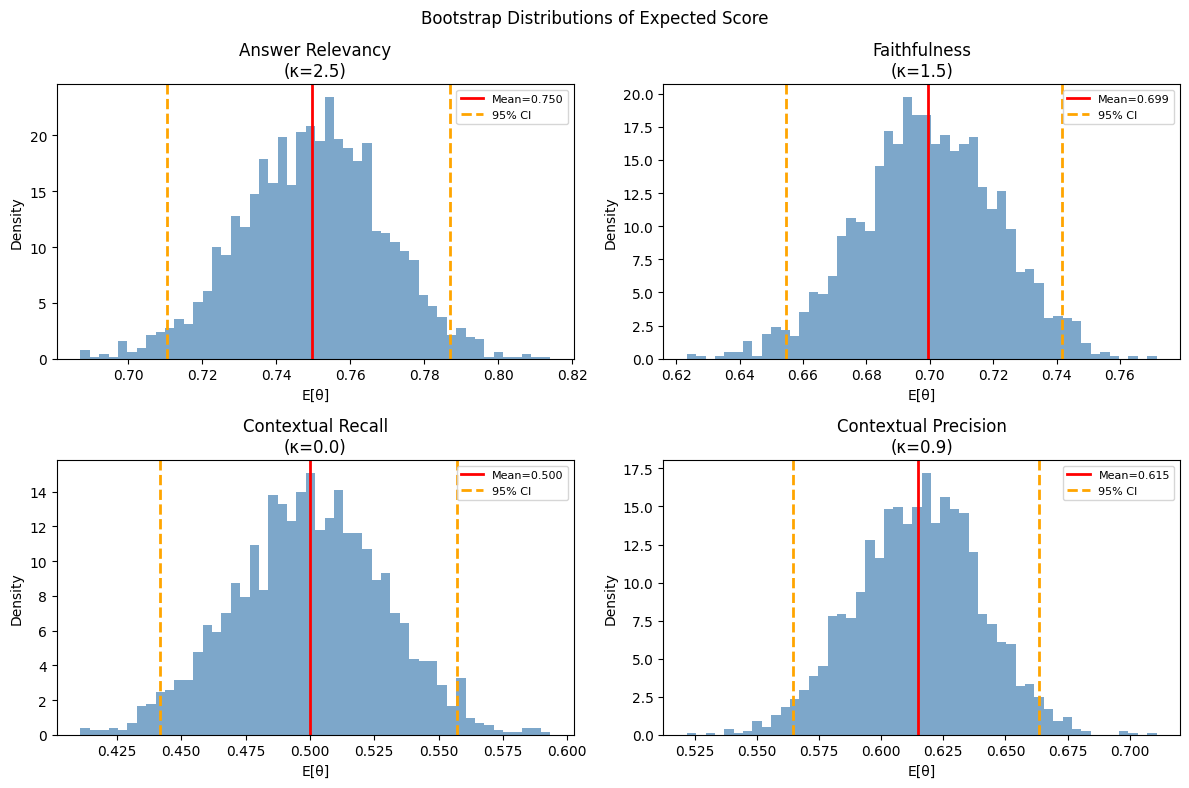

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, metric in enumerate(metric_names):
    ax = axes[idx]
    data = bootstrap_results[metric]
    
    ax.hist(data['distribution'], bins=50, density=True, alpha=0.7, color='steelblue')
    ax.axvline(data['mean'], color='red', lw=2, label=f"Mean={data['mean']:.3f}")
    ax.axvline(data['ci_lower'], color='orange', ls='--', lw=2)
    ax.axvline(data['ci_upper'], color='orange', ls='--', lw=2, label=f"95% CI")
    ax.set_xlabel('E[θ]')
    ax.set_ylabel('Density')
    ax.set_title(f"{metric}\n(κ={data['kappa']:.1f})")
    ax.legend(fontsize=8)

plt.suptitle('Bootstrap Distributions of Expected Score', fontsize=12)
plt.tight_layout()
plt.show()

In [33]:
posteriors_df['ci_width'] = posteriors_df['ci_upper'] - posteriors_df['ci_lower']
posteriors_df.groupby('metric')[['score', 'ci_lower', 'ci_upper', 'ci_width']].mean().round(4)

,score,ci_lower,ci_upper,ci_width
metric,,,,
Answer Relevancy,0.9498,0.6611,0.9794,0.3183
Contextual Precision,0.8725,0.5963,0.9339,0.3377
Contextual Recall,0.9400,0.6723,0.9549,0.2826
Faithfulness,0.9700,0.6847,0.9851,0.3004


In [ ]:
# from ai_eval.services.file import JSONService
# from ai_eval.config import global_config as glob

# json = JSONService(path="simple_benchmark_tfidf_N100.json", root_path=glob.DATA_PKG_DIR, verbose=True)

# json.doWrite(scorer.get_overall_metrics())